# Verfahrenswahrscheinlichkeit bei festem $p_0$

Die linke Grafik zeigt 100 Realisationen von $H_n$ auf der
Vertikalen $p=p_0$. Die rechte Grafik zeigt die 100 zugehörigen
Wilson-Konfidenzintervalle. Beide Darstellungen beruhen auf
denselben Stichproben und verbinden damit die Sicht im
$(p,h)$-Raum mit der üblichen Intervallgrafik.


## Eingaben


    Alle veränderbaren Eingaben stehen in der kleinen Klasse `Config`.
    Danach folgen getrennt die mathematische Berechnung und die Erzeugung
    der Grafik. Das Notebook ist selbstständig lauffähig.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


@dataclass(frozen=True)
class Config:
    n: int = 80
    gamma: float = 0.95
    p0: float = 0.40
    number_of_samples: int = 100
    sample_seed: int = 20260007
    background_seed: int = 20260630
    background_simulations_per_p: int = 40
    show_background_cloud: bool = True
    show_prediction_bounds_on_right: bool = True
    save_figure: bool = False
    output_dir: str = "fig"


cfg = Config()


## Gemeinsame Daten für beide Darstellungen

Die normalapproximativen Prognosegrenzen bei festem $p_0$ sind

$$
p_0\pm z\sqrt{\frac{p_0(1-p_0)}{n}}.
$$

Ein Wert $h$ liegt genau dann zwischen diesen Grenzen, wenn das
durch Inversion gewonnene Wilson-Intervall den Parameterwert
$p_0$ enthält. Diese Gleichheit wird im Programm ausdrücklich
überprüft.


In [2]:
z = norm.ppf((1.0 + cfg.gamma) / 2.0)


def wilson_interval(x: int) -> tuple[float, float]:
    h = x / cfg.n
    denominator = 1.0 + z**2 / cfg.n
    center = (h + z**2 / (2.0 * cfg.n)) / denominator
    half_width = (
        z
        * math.sqrt(
            h * (1.0 - h) / cfg.n
            + z**2 / (4.0 * cfg.n**2)
        )
        / denominator
    )
    return center - half_width, center + half_width


rng = np.random.default_rng(cfg.sample_seed)
x = rng.binomial(cfg.n, cfg.p0, size=cfg.number_of_samples)
h = x / cfg.n

intervals = np.array([wilson_interval(int(value)) for value in x])
lower_ci = intervals[:, 0]
upper_ci = intervals[:, 1]
covers = (lower_ci <= cfg.p0) & (cfg.p0 <= upper_ci)

prediction_half_width = z * math.sqrt(
    cfg.p0 * (1.0 - cfg.p0) / cfg.n
)
lower_prediction = cfg.p0 - prediction_half_width
upper_prediction = cfg.p0 + prediction_half_width
inside_prediction = (
    (h >= lower_prediction - 1e-12)
    & (h <= upper_prediction + 1e-12)
)

assert np.array_equal(inside_prediction, covers)
print(
    f"{int(covers.sum())} von {cfg.number_of_samples} "
    "Realisationen liegen im Prognoseintervall."
)


98 von 100 Realisationen liegen im Prognoseintervall.


## Zeichenfunktionen


In [3]:
def draw_left_panel(ax: plt.Axes) -> None:
    if cfg.show_background_cloud:
        background_rng = np.random.default_rng(cfg.background_seed)
        p_values = np.linspace(0.0, 1.0, 501)
        p_points = np.repeat(
            p_values,
            cfg.background_simulations_per_p,
        )
        x_background = np.concatenate([
            background_rng.binomial(
                cfg.n,
                p,
                size=cfg.background_simulations_per_p,
            )
            for p in p_values
        ])
        h_background = x_background / cfg.n

        ax.scatter(p_points, h_background, s=5, alpha=0.035)

        half_width = z * np.sqrt(
            p_values * (1.0 - p_values) / cfg.n
        )
        ax.plot(
            p_values,
            np.clip(p_values - half_width, 0.0, 1.0),
            linewidth=1.8,
            color="tab:blue",
        )
        ax.plot(
            p_values,
            np.clip(p_values + half_width, 0.0, 1.0),
            linewidth=1.8,
            color="tab:blue",
        )
        ax.plot(
            p_values,
            p_values,
            linestyle="--",
            linewidth=1.0,
        )

    ax.axvline(cfg.p0, linestyle="--", linewidth=1.5)
    ax.plot(
        [cfg.p0, cfg.p0],
        [lower_prediction, upper_prediction],
        linewidth=8.0,
        alpha=0.22,
        solid_capstyle="butt",
        color="tab:blue",
    )
    ax.scatter(
        [cfg.p0, cfg.p0],
        [lower_prediction, upper_prediction],
        marker="_",
        s=210,
        linewidths=1.8,
        color="tab:blue",
    )

    p_positions = np.full(h.shape, cfg.p0)
    ax.scatter(
        p_positions[covers],
        h[covers],
        s=16,
        alpha=0.22,
        color="tab:green",
        zorder=7,
    )
    ax.scatter(
        p_positions[~covers],
        h[~covers],
        marker="x",
        s=62,
        linewidths=1.9,
        color="tab:red",
        zorder=8,
    )

    ax.annotate(
        r"$p_0$",
        xy=(cfg.p0, 0.0),
        xytext=(0, -20),
        textcoords="offset points",
        ha="center",
        va="top",
        fontsize=14,
        annotation_clip=False,
    )
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$p$", fontsize=17)
    ax.set_ylabel(r"$h$", fontsize=17, rotation=0, labelpad=14)
    ax.tick_params(labelsize=12)


def draw_right_panel(ax: plt.Axes) -> None:
    y = np.arange(1, cfg.number_of_samples + 1)

    ax.hlines(y, lower_ci, upper_ci, linewidth=1.05, color="0.50")
    ax.scatter(
        h[covers],
        y[covers],
        s=16,
        alpha=0.70,
        color="tab:green",
        zorder=3,
    )
    ax.scatter(
        h[~covers],
        y[~covers],
        marker="x",
        s=62,
        linewidths=1.9,
        color="tab:red",
        zorder=4,
    )
    ax.axvline(cfg.p0, linestyle="--", linewidth=1.5)

    if cfg.show_prediction_bounds_on_right:
        ax.axvline(
            lower_prediction,
            linestyle=":",
            linewidth=1.25,
            color="tab:blue",
        )
        ax.axvline(
            upper_prediction,
            linestyle=":",
            linewidth=1.25,
            color="tab:blue",
        )

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0, cfg.number_of_samples + 1)
    ax.set_xlabel(r"$p$", fontsize=17)
    ax.set_ylabel("Stichprobe", fontsize=14)

    tick_step = max(1, cfg.number_of_samples // 5)
    ticks = list(range(1, cfg.number_of_samples + 1, tick_step))
    if cfg.number_of_samples not in ticks:
        ticks.append(cfg.number_of_samples)
    ax.set_yticks(ticks)
    ax.tick_params(labelsize=11)


## Gemeinsame Grafik

Die Teilgrafiken erhalten bewusst keine Buchstaben. Im Text kann
auf die linke und die rechte Grafik verwiesen werden.


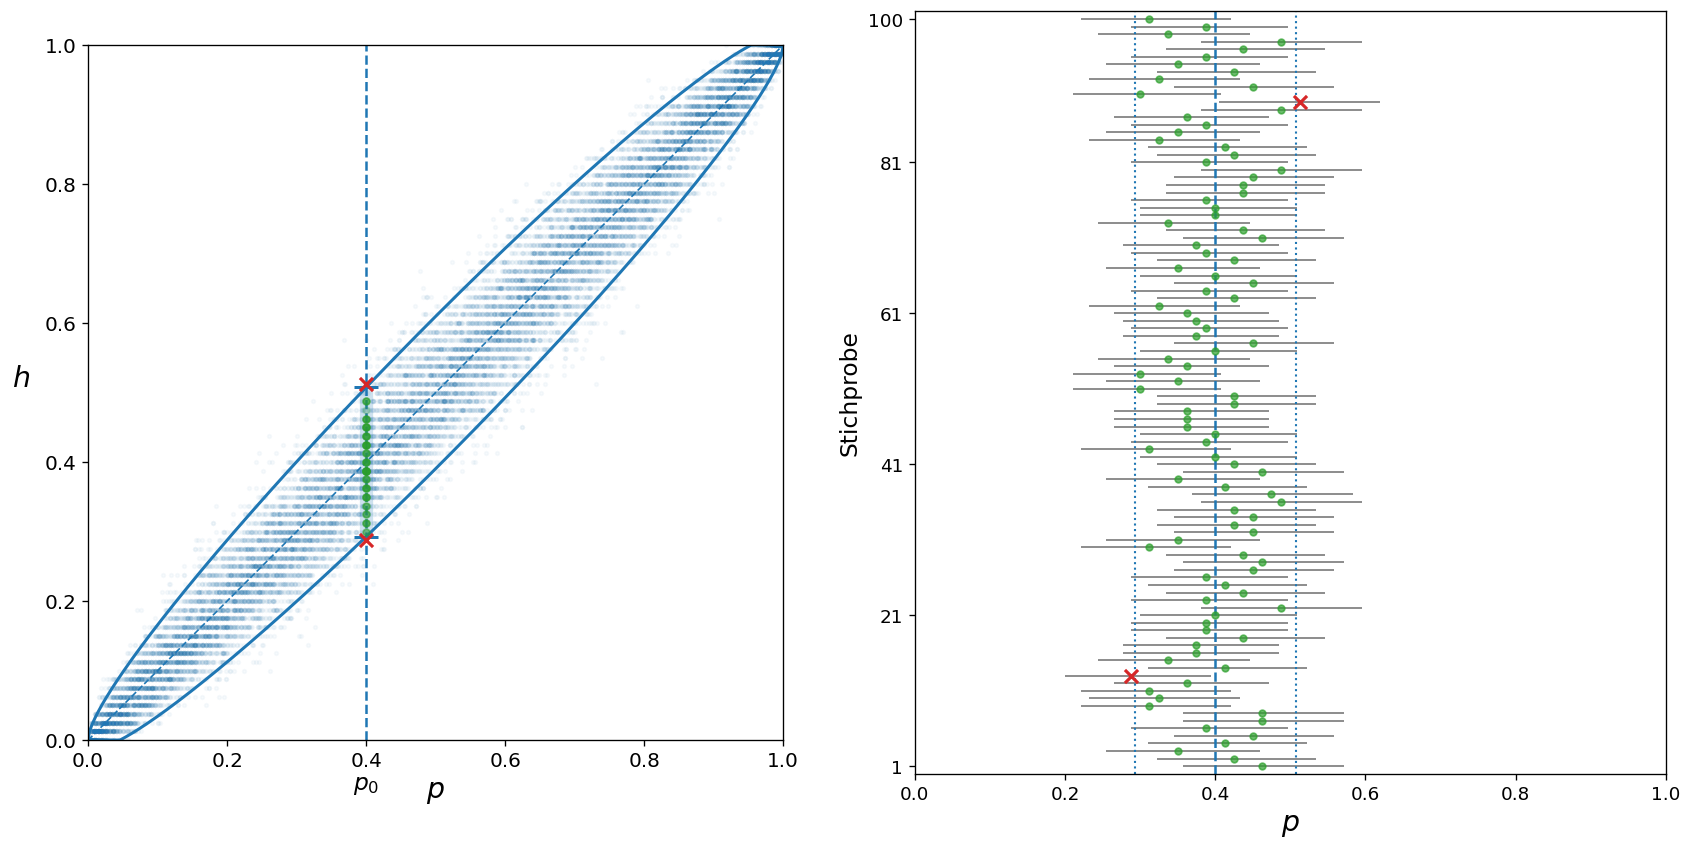

In [4]:
fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    figsize=(14.2, 7.2),
    gridspec_kw={"width_ratios": [1.0, 1.08]},
)
draw_left_panel(ax_left)
draw_right_panel(ax_right)
fig.tight_layout(w_pad=2.4)

if cfg.save_figure:
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        output_dir / "07_verfahrenswahrscheinlichkeit.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        output_dir / "07_verfahrenswahrscheinlichkeit.png",
        dpi=240,
        bbox_inches="tight",
    )

plt.show()


## Mögliche Veränderungen

Der Seed erzeugt eine neue Serie von 100 Stichproben. Besonders
aufschlussreich sind außerdem Variationen von $p_0$, $n$ und
$\gamma$. Die beiden Darstellungen bleiben dabei stets gekoppelt.
